In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from module_quarter import make_ff_factors, performance_metrics
import warnings
warnings.filterwarnings("error", category=RuntimeWarning)

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
KOSPI               = pd.read_csv('../../00_input/KOSPI_index.csv', index_col='Date', parse_dates=True)
adj_close_df        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_adj_close.csv', index_col='Date', parse_dates=True)
mkt_cap             = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_mkt_cap.csv', index_col='Date', parse_dates=True)
factors             = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)
total_adj_close     = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_total_adj_close.csv', index_col='Date', parse_dates=True)
trading_value_60    = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_trading_value_60.csv', index_col='Date', parse_dates=True)
trading_value       = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_trading_value.csv', index_col='Date', parse_dates=True)

# 아래는 모두 한 분기 래그 필요
# 연결 (1989-12-31~)
gross_profit        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_gross_profit.csv', index_col='Date', parse_dates=True)
cashflow            = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_cash_flow.csv', index_col='Date', parse_dates=True)
sales               = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_sales.csv', index_col='Date', parse_dates=True)
total_assets        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_total_asset.csv', index_col='Date', parse_dates=True)

# 분기 (2001-01-31~)
ROE                 = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_ROE.csv', index_col='Date', parse_dates=True)
ROA                 = pd.read_csv('../../00_input/KOSPI_KOSDAQ_제조업_ROA.csv', index_col='Date', parse_dates=True)

---
##### **데이터 전처리**

In [3]:
# 연결
gross_profit = gross_profit.shift(14)
cashflow     = cashflow.shift(14)
sales        = sales.shift(14)
total_assets = total_assets.shift(14)

# 분기
ROE = ROE.shift(5)
ROA = ROA.shift(5)

In [4]:
GPOA = gross_profit / total_assets
CFOA = cashflow / total_assets
GMAR = gross_profit / sales

In [5]:
GPOA_rank = GPOA.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")
CFOA_rank = CFOA.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")
GMAR_rank = GMAR.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")
ROA_rank  = ROA.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")
ROE_rank  = ROE.rank(axis=1, ascending=False, method="first", na_option="keep").astype("Int64")

In [6]:
def zscore_by_date(rank_df: pd.DataFrame) -> pd.DataFrame:
    # rank_df: index=Date, columns=기업
    mean = rank_df.mean(axis=1, skipna=True)
    std = rank_df.std(axis=1, skipna=True, ddof=0)  # 모집단 표준편차(ddof=0) 권장
    std_safe = std.where(std != 0)  # std=0이면 NaN 처리
    z = rank_df.sub(mean, axis=0).div(std_safe, axis=0)
    return z

GPOA_z = zscore_by_date(GPOA_rank.astype(float))
CFOA_z = zscore_by_date(CFOA_rank.astype(float))
GMAR_z = zscore_by_date(GMAR_rank.astype(float))
ROA_z  = zscore_by_date(ROA_rank.astype(float))
ROE_z  = zscore_by_date(ROE_rank.astype(float))

In [7]:
# 낮을수록 quality, 높을수록 junk
profitability_v3 = pd.concat(
    [GPOA_z, CFOA_z, GMAR_z, ROA_z, ROE_z],
    keys=["GPOA", "CFOA", "GMAR", "ROA", "ROE"]
).groupby(level=1).mean()


In [8]:
# from pathlib import Path

# # 원하는 경로 (Windows 예시)
# out_path = Path(r"C:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\00_input\profitability_제조업_분기_v3.csv")

# profitability_v3.to_csv(out_path, encoding="utf-8-sig", index_label="Date")

In [9]:
factor_df = profitability_v3

In [10]:
# 월간 데이터 계산
monthly_rets      = total_adj_close.resample('QE').last().pct_change(fill_method=None)

# 수익률 윈저라이징
monthly_rets_wins = monthly_rets.clip(
    lower=monthly_rets.quantile(0.01),
    upper=monthly_rets.quantile(0.99),
    axis=1
)

In [11]:
# 일별 수익률과 거래대금을 이용해 Amihud illiquidity 계산
daily_ret        = adj_close_df.pct_change(fill_method=None)
daily_illiq      = (daily_ret.abs()/trading_value)
illiq            = daily_illiq.resample('QE').mean()

---
##### **리밸런싱 날짜 설정**

In [12]:
# 백테스트 기간을 설정하여 월말 날짜 리스트 생성
start_point = '2006-03-31'
end_point   = '2026-02-28'

month_ends  = pd.date_range(start=start_point, end=end_point, freq='QE')

In [13]:
# 종목 수 선정
n                      = 20  

# 가중방식 선택
weight_method_temp     = "Cap"  # ['Equal'(동일가중), Cap'(시가총액가중)]

# 유동성 하위 종목 제외
trading_threshold      = 0.10     # 유동성 하위 종목 제외

# 거래대금 설정
high_cost              = 0.008    # 80bp
low_cost               = 0.003    # 30bp
illiq_threshold        = 0.80     # Amihud 유동성 기준 상위 20%

portfolio_return       = pd.Series(dtype=float)
total_trade            = pd.Series(dtype=float)

initial_NAV            = 1        # 초기값
NAV                    = initial_NAV

---
##### **전체 기간 포트폴리오 수익률 계산**

In [14]:
portfolio_return = pd.Series(index=month_ends, dtype=float)
total_trade      = pd.Series(index=month_ends, dtype=float)
prev_portfolio   = pd.Series(dtype=float)

portfolio_return[month_ends[0]] = 0.0
NAV = initial_NAV

In [15]:
# for i in range(len(month_ends) - 1):

#     # 매기간 날짜 업데이트
#     start_date  = month_ends[i]
#     end_date    = month_ends[i + 1]

#     # 거래대금 하위 종목 제외
#     trading_today      = trading_value_60.loc[start_date].dropna()
#     filtered           = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

#     factor_filtered    = factor_df.loc[start_date, filtered].dropna()

#     # 종목 선정
#     basket = factor_filtered.nsmallest(n).index

#     # 유동성 반영
#     illiq_startdate = illiq.loc[start_date].dropna()
#     threshold       = illiq_startdate.quantile(illiq_threshold)
#     illiquid_top20  = illiq_startdate[illiq_startdate >= threshold].index

#     # 가중방식 선택
#     prev_weights   = prev_portfolio / prev_portfolio.sum()
    
#     # 동일가중
#     if weight_method_temp == 'Equal':
#         target_weights = pd.Series(1.0/len(basket), index=basket)

#     # 시가총액가중
#     else:
#         cap = mkt_cap.loc[start_date, basket]
#         target_weights = cap/cap.sum()

#     # 거래비용 반영
#     all_index = target_weights.index.union(prev_weights.index)
#     target_w = target_weights.reindex(all_index, fill_value=0)
#     prev_w   = prev_weights.reindex(all_index, fill_value=0)

#     delta_w   = target_w - prev_w
#     trade_amounts = abs(delta_w) * NAV
#     cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)

#     trade_cost = (trade_amounts * cost_rate).sum()

#     NAV_new = NAV - trade_cost
    
#     current_portfolio_value = target_weights * NAV_new

#     # 당기 포트폴리오 최종 가치 계산
#     ret_seg              = monthly_rets_wins.loc[end_date, basket]
#     next_portfolio_value = current_portfolio_value * (ret_seg + 1)

#     # 당기 포트폴리오 수익률 계산
#     NAV_new       = next_portfolio_value.sum()
#     portfolio_ret = NAV_new / NAV - 1

#     # prev_portfolio 업데이트
#     prev_portfolio = next_portfolio_value

#     # NAV 업데이트
#     NAV = NAV_new

#     # 총 거래금액 저장
#     total_trade.loc[start_date] = trade_amounts.sum()
    
#     # 포트폴리오 수익률 저장
#     portfolio_return.loc[end_date] = portfolio_ret

In [16]:
pct = 0.2

for i in range(len(month_ends) - 1):

    # 매기간 날짜 업데이트
    start_date = month_ends[i]
    end_date   = month_ends[i + 1]

    # 거래대금 하위 종목 제외
    trading_today = trading_value_60.loc[start_date].dropna()
    filtered = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

    factor_filtered = factor_df.loc[start_date, filtered].dropna()

    # 종목 선정: factor 하위 20%
    if factor_filtered.empty:
        portfolio_return.loc[end_date] = np.nan
        total_trade.loc[start_date] = 0.0
        continue

    n_select = max(1, int(np.ceil(len(factor_filtered) * pct)))
    basket = factor_filtered.nsmallest(n_select).index
    
    # 유동성 반영
    illiq_startdate = illiq.loc[start_date].dropna()
    threshold = illiq_startdate.quantile(illiq_threshold)
    illiquid_top20 = illiq_startdate[illiq_startdate >= threshold].index

    # 가중방식 선택
    prev_weights = prev_portfolio / prev_portfolio.sum() if prev_portfolio.sum() != 0 else pd.Series(dtype=float)

    # 동일 가중
    if weight_method_temp == 'Equal':
        target_weights = pd.Series(1.0 / len(basket), index=basket)

    # 시가 총액 가중
    else:
        cap = mkt_cap.loc[start_date, basket].dropna()
        target_weights = cap / cap.sum()
        basket = target_weights.index  # 결측 cap 제거 반영

    # 거래비용 반영
    all_index = target_weights.index.union(prev_weights.index)
    target_w = target_weights.reindex(all_index, fill_value=0)
    prev_w = prev_weights.reindex(all_index, fill_value=0)

    delta_w = target_w - prev_w
    trade_amounts = abs(delta_w) * NAV
    cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)

    trade_cost = (trade_amounts * cost_rate).sum()

    NAV_new = NAV - trade_cost
    current_portfolio_value = target_weights * NAV_new

    # 당기 포트폴리오 최종 가치 계산
    ret_seg = monthly_rets_wins.loc[end_date, basket].dropna()
    common = current_portfolio_value.index.intersection(ret_seg.index)
    # print(end_date, common)
    if len(common) == 0:
        portfolio_return.loc[end_date] = np.nan
        total_trade.loc[start_date] = trade_amounts.sum()
        continue

    next_portfolio_value = current_portfolio_value.loc[common] * (ret_seg.loc[common] + 1)

    # 당기 포트폴리오 수익률 계산
    NAV_new = next_portfolio_value.sum()
    portfolio_ret = NAV_new / NAV - 1

    # prev_portfolio 업데이트
    prev_portfolio = next_portfolio_value

    # NAV 업데이트
    NAV = NAV_new

    # 총 거래금액 저장
    total_trade.loc[start_date] = trade_amounts.sum()

    # 포트폴리오 수익률 저장
    portfolio_return.loc[end_date] = portfolio_ret


In [17]:
portfolio_return.tail()

2024-12-31   -0.019427
2025-03-31    0.050503
2025-06-30    0.187176
2025-09-30    0.173629
2025-12-31    0.362769
Freq: QE-DEC, dtype: float64

---
##### **NAV 계산 및 OUTPUT 데이터 전처리**

In [18]:
portfolio_NAV = (1 + portfolio_return).cumprod() * initial_NAV

In [19]:
# Portfolio 데이터 생성
df = pd.concat(
    [portfolio_return, portfolio_NAV, total_trade], 
    axis=1
)

df.columns = ["Return", "NAV", "Trade"]
df.index.name = "Date"

# 초기값 저장
df.loc[df.index[0], "NAV"] = initial_NAV

portfolio = df

---
### **1. 수익률 분석**

포트폴리오 초과수익률 = 상수 + 시장 초과수익률 + SMB + HML + MOM + 잔차

In [20]:
factors_quarterly = make_ff_factors(factors)[:-1]

In [21]:
# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([df['Return'], factors_quarterly], axis=1, join="inner").dropna()

In [22]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차

In [23]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     447.5
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           1.70e-51
Time:                        20:06:02   Log-Likelihood:                 163.25
No. Observations:                  80   AIC:                            -316.5
Df Residuals:                      75   BIC:                            -304.6
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0183      0.003      5.252      0.0

---
### **2. 성과지표 계산**

In [24]:
metrics = performance_metrics(portfolio)

In [25]:
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

CAGR: 0.1172
Volatility (ann.): 0.1844
Sharpe Ratio: 0.6967
MDD: -0.3715
Average Turnover (quarterly): 0.1618


---
**NAV Plot**

In [26]:
df_ret = pd.concat([portfolio['Return'].dropna(), factors_quarterly['KOSPI']], axis=1, join='inner')
df_ret.columns = ['Portfolio', 'KOSPI']
df_ret.index.name = 'Date'

In [27]:
df_nav = (1 + df_ret).cumprod()
df_nav.columns = ['Portfolio', 'KOSPI']

In [28]:
df_nav

,Portfolio,KOSPI
Date,,
2006-03-31,1.000000,0.985667
2006-06-30,0.972262,0.938943
2006-09-30,1.023583,0.994229
2006-12-31,1.069759,1.039939
2007-03-31,1.032677,1.053053
...,...,...
2024-12-31,4.474532,1.739555
2025-03-31,4.700508,1.798734
2025-06-30,5.580330,2.226886


<Axes: xlabel='Date'>

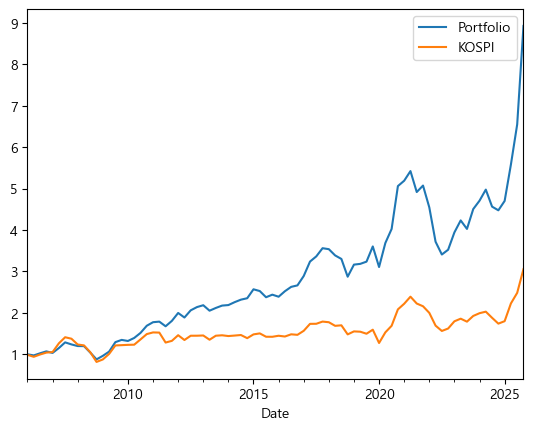

In [29]:
df_nav.plot()

---
**로그누적수익률 Plot**

<Axes: xlabel='Date'>

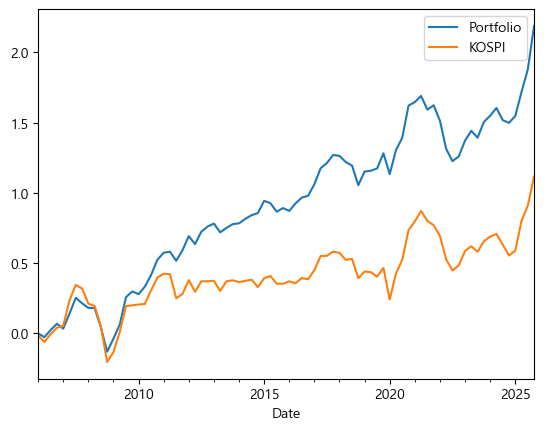

In [30]:
np.log1p(df_ret).cumsum().plot()